In [1]:
from matplotlib import gridspec
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
np.float = float
from matplotlib.colors import LinearSegmentedColormap
import cartopy
from netCDF4 import Dataset
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

In [2]:
### load interp dates
d1 = datetime.date(2010, 10, 1)
d2 = datetime.date(2022, 7, 31)
dates = [d1 + datetime.timedelta(days=x) for x in range((d2-d1).days + 1)]
str_dates = [date.strftime('%Y%m%d') for date in dates]

### load bear data

In [3]:
### make collars dataframe
datapath_collars = '/Users/carmennab/Dropbox/pb_new/data/bears/collars_combined_ease.csv'
data = pd.read_csv(datapath_collars,usecols=['longitude','latitude','ID','date']).dropna()
data['datetime'] = [datetime.datetime.strptime(date, '%Y-%m-%d') for date in data['date']]
collars_df = data.drop(columns=['date'])

In [4]:
### load first location for each collar

first_collars = []

for x in set(collars_df['ID']):
    x_data = collars_df[collars_df['ID']==x]
    first_collars.append({'longitude':x_data['longitude'].iloc[0],'latitude':x_data['latitude'].iloc[0],'ID':x})
    
first_collars = pd.DataFrame(first_collars)
first_collars

,longitude,latitude,ID
0,-92.128000,58.439000,X19992
1,-88.823000,56.841000,X33947
2,-93.724172,57.574018,X19899
3,-93.584000,61.075000,X17471
4,-93.679862,57.578702,X19295
...,...,...,...
198,-93.478761,58.192992,X12689
199,-93.742175,58.071628,X12205
200,-92.812543,58.043561,X33382
201,-93.895984,58.419843,X33529


In [5]:
### make eartags dataframe
datapath_collars = '/Users/carmennab/Dropbox/pb_new/data/bears/eartags_combined_ease.csv'
data = pd.read_csv(datapath_collars,usecols=['longitude','latitude','ID','date']).dropna()
data['datetime'] = [datetime.datetime.strptime(date, '%Y-%m-%d') for date in data['date']]
eartags_df = data.drop(columns=['date'])

In [6]:
### load first location for each eartag

first_eartags = []

for x in set(eartags_df['ID']):
    x_data = eartags_df[eartags_df['ID']==x]
    first_eartags.append({'longitude':x_data['longitude'].iloc[0],'latitude':x_data['latitude'].iloc[0],'ID':x})
    
first_eartags = pd.DataFrame(first_eartags)
first_eartags

,longitude,latitude,ID
0,-92.128000,58.439000,X19992
1,-88.823000,56.841000,X33947
2,-93.584000,61.075000,X17471
3,-88.834618,56.842495,X33955
4,-94.149000,59.411000,X34007
...,...,...,...
96,-93.698000,58.965000,X32953
97,-111.807000,33.381000,X33257
98,-93.964000,58.789000,X34132
99,-94.740000,58.966000,X19477


In [7]:
collars_df

,ID,longitude,latitude,datetime
0,X11940,-93.405290,58.420014,2010-09-08
1,X11940,-93.405375,58.420014,2010-09-08
2,X11940,-93.405375,58.420100,2010-09-08
3,X11940,-93.405375,58.420014,2010-09-08
4,X11940,-93.405375,58.420014,2010-09-09
...,...,...,...,...
450814,X33697,-89.668000,56.690000,2022-09-01
450815,X33697,-89.666000,56.690000,2022-09-01
450816,X33697,-89.655000,56.697000,2022-09-01
450817,X33697,-89.684000,56.693000,2022-09-01


In [8]:
def add_scalebar(ax, length_km=100, location=(0.1, 0.05), linewidth=3, text_offset=0.015):
    """
    Adds a km scale bar to a Cartopy map.
    
    ax            : Cartopy GeoAxes
    length_km     : length of the scale bar in kilometers
    location      : (x,y) location in axis coordinates (0–1)
    linewidth     : thickness of the bar
    text_offset   : label offset above bar (axis coords)
    """
    # projection & transformer
    proj = pyproj.Geod(ellps='WGS84')
    
    # pick a reference point at the bottom center of the axes
    extent = ax.get_extent(ccrs.PlateCarree())
    lon0 = (extent[0] + extent[1]) / 2
    lat0 = extent[2] + (extent[3] - extent[2]) * 0.05  # near bottom
    
    # compute longitude shift corresponding to "length_km"
    lon1, lat1, _ = proj.fwd(lon0, lat0, 90, length_km * 1000)  # 90° = east
    
    # convert to axis coordinates
    xp0, yp0 = ax.projection.transform_point(lon0, lat0, ccrs.PlateCarree())
    xp1, yp1 = ax.projection.transform_point(lon1, lat1, ccrs.PlateCarree())

    # convert to display coordinates
    trans = ax.transData
    inv = ax.transAxes.inverted()
    x0a, y0a = inv.transform(trans.transform((xp0, yp0)))
    x1a, y1a = inv.transform(trans.transform((xp1, yp1)))

    # shift to the requested location
    dx = location[0] - x0a
    dy = location[1] - y0a
    x0 = x0a + dx; y0 = y0a + dy
    x1 = x1a + dx; y1 = y1a + dy

    # draw bar + text
    ax.plot([x0, x1], [y0, y0], transform=ax.transAxes, color='black', linewidth=linewidth)
    ax.text((x0 + x1)/2, y0 + text_offset, f"{length_km} km",
            transform=ax.transAxes, ha='center', va='bottom', fontsize=10)

### plot figure

In [9]:
figpath = '/Users/carmennab/Dropbox/Apps/Overleaf/CRiceS_PolarBears_HB/figures/'
datapath_aux = '/Users/carmennab/Dropbox/pb_new/auxiliary/'
ease_lons = np.load(f'{datapath_aux}lon_edge.npy')
ease_lats = np.load(f'{datapath_aux}lat_edge.npy')

[]

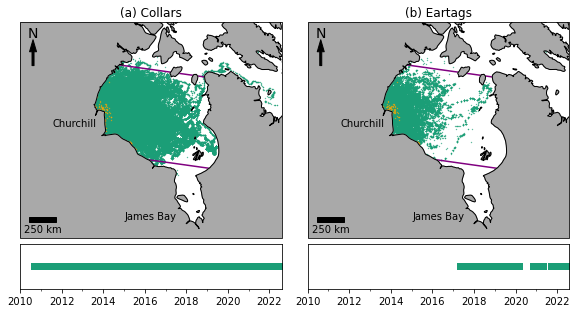

In [10]:
fig = plt.figure(figsize=(15,5))
spec = gridspec.GridSpec(ncols=3, nrows=2,height_ratios=[5,1],hspace=0.,wspace=0.1)
lons = [-100, -76, -76, -100]
lats = [55,  55,  62,   62]

# plot collars
ax1 = fig.add_subplot(spec[0],projection=ccrs.NorthPolarStereo(central_longitude=-80))
ax1.add_feature(cartopy.feature.OCEAN, color='white', edgecolor='black')
ax1.set_extent([-100, -70, 50, 65], ccrs.PlateCarree())
ax1.scatter(collars_df['longitude'],collars_df['latitude'],c='#1b9e77',s=1,transform=ccrs.PlateCarree())
ax1.scatter(first_collars['longitude'],first_collars['latitude'],c='orange',s=1,transform=ccrs.PlateCarree())
ax1.fill(lons,lats,transform=ccrs.PlateCarree(),facecolor='none',edgecolor='purple',linewidth=1.5)
ax1.add_feature(cartopy.feature.LAND, color='darkgrey',zorder=1)
ax1.set_title('(a) Collars')
ax1.coastlines()

ax1.text(0.05, 0.95, 'N', transform=ax1.transAxes, ha='center', va='center', fontsize=14)
ax1.annotate('', xy=(0.05, 0.92), xytext=(0.05, 0.8), arrowprops=dict(facecolor='black', width=2, headwidth=7),
    xycoords=ax1.transAxes)

ax1.add_artist(AnchoredSizeBar(ax1.transData,
                           250_000, '250 km', 'lower left', 
                           pad=0.3,
                           color='black',
                           frameon=False,
                           size_vertical=50000))
ax1.text(0.21, 0.53, 'Churchill', transform=ax1.transAxes, ha='center', va='center', fontsize=10)
ax1.text(0.5, 0.1, 'James Bay', transform=ax1.transAxes, ha='center', va='center', fontsize=10)

ax1 = fig.add_subplot(spec[3])
ax1.scatter(collars_df['datetime'],np.full(len(collars_df['datetime']),1),c='#1b9e77',marker='s')
ax1.set_xticks([datetime.date(year, 1, 1) for year in np.arange(2008,2023,2)])
ax1.set_xticklabels(np.arange(2008,2023,2))
ax1.set_xticks([datetime.date(year, 1, 1) for year in np.arange(2009,2023,2)],minor=True)
ax1.set_xlim([datetime.date(2010, 1, 1),datetime.date(2022, 7, 31)])
ax1.set_yticks([])

# plot eartags
ax1 = fig.add_subplot(spec[1],projection=ccrs.NorthPolarStereo(central_longitude=-80))
ax1.add_feature(cartopy.feature.OCEAN, color='white', edgecolor='black')
ax1.set_extent([-100, -70, 50, 65], ccrs.PlateCarree())
ax1.scatter(eartags_df['longitude'],eartags_df['latitude'],c='#1b9e77',s=1,transform=ccrs.PlateCarree())
ax1.scatter(first_eartags['longitude'],first_eartags['latitude'],c='orange',s=1,transform=ccrs.PlateCarree())
ax1.fill(lons,lats,transform=ccrs.PlateCarree(),facecolor='none',edgecolor='purple',linewidth=1.5)
ax1.add_feature(cartopy.feature.LAND, color='darkgrey',zorder=1)
ax1.set_title('(b) Eartags')
ax1.coastlines()

ax1.text(0.05, 0.95, 'N', transform=ax1.transAxes, ha='center', va='center', fontsize=14)
ax1.annotate('', xy=(0.05, 0.92), xytext=(0.05, 0.8), arrowprops=dict(facecolor='black', width=2, headwidth=7),
    xycoords=ax1.transAxes)

ax1.add_artist(AnchoredSizeBar(ax1.transData,
                           250_000, '250 km', 'lower left', 
                           pad=0.3,
                           color='black',
                           frameon=False,
                           size_vertical=50000))
ax1.text(0.21, 0.53, 'Churchill', transform=ax1.transAxes, ha='center', va='center', fontsize=10)
ax1.text(0.5, 0.1, 'James Bay', transform=ax1.transAxes, ha='center', va='center', fontsize=10)

ax1 = fig.add_subplot(spec[4])
ax1.scatter(eartags_df['datetime'],np.full(len(eartags_df['datetime']),1),c='#1b9e77',marker='s')
ax1.set_xticks([datetime.date(year, 1, 1) for year in np.arange(2008,2023,2)])
ax1.set_xticks([datetime.date(year, 1, 1) for year in np.arange(2009,2023,2)],minor=True)
ax1.set_xticklabels(np.arange(2008,2023,2))
ax1.set_xlim([datetime.date(2010, 1, 1),datetime.date(2022, 7, 31)])
ax1.set_yticks([])

# plt.savefig(f'{figpath}bear_locs.jpg',bbox_inches = "tight", dpi = 400)